# TASK 3: IMPLEMENTATION OF CONVOLUTIONAL NEURAL NETWORKS (CNNs) FOR IMAGE CLASSIFICATION

# EXPERIMENT NO. 3
## IMPLEMENTATION OF CONVOLUTIONAL NEURAL NETWORKS (CNNs) FOR IMAGE CLASSIFICATION

**Name:** AJAIKUMAR M

**Roll No:** 24BAD005

# TASK A — DATASET PREPARATION

Import Libraries

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("TensorFlow version:", tf.__version__)
print("Libraries imported successfully!")

TensorFlow version: 2.20.0
Libraries imported successfully!


Load the CIFAR-10 Dataset

In [ ]:
# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", x_test.shape)
print("Testing labels:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1639s 10us/step
Training images: (50000, 32, 32, 3)
Training labels: (50000, 1)
Testing images: (10000, 32, 32, 3)
Testing labels: (10000, 1)


Define CIFAR-10 Class Names

In [ ]:
# CIFAR-10 class names
class_names = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

print("Classes:")
for i, name in enumerate(class_names):
    print(i, ":", name)

Classes:
0 : airplane
1 : automobile
2 : bird
3 : cat
4 : deer
5 : dog
6 : frog
7 : horse
8 : ship
9 : truck


Check Dataset Details

In [ ]:
# Check dataset details

print("Image shape:", x_train[0].shape)
print("First image label:", y_train[0][0])
print("First image class:", class_names[y_train[0][0]])

print("\nPixel value range:")
print("Minimum:", x_train.min())
print("Maximum:", x_train.max())

Image shape: (32, 32, 3)
First image label: 6
First image class: frog

Pixel value range:
Minimum: 0
Maximum: 255


Display Sample Images

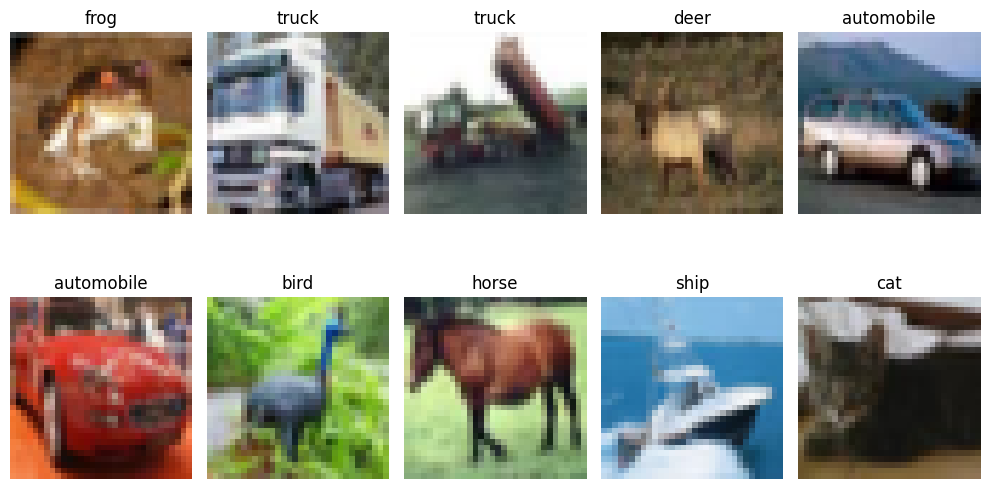

In [ ]:
# Display sample images from CIFAR-10

plt.figure(figsize=(10, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.tight_layout()
plt.show()

Normalize the Images

In [ ]:
# Normalize pixel values from 0-255 to 0-1

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print("Training pixel range:", x_train.min(), "to", x_train.max())
print("Testing pixel range:", x_test.min(), "to", x_test.max())

Training pixel range: 0.0 to 1.0
Testing pixel range: 0.0 to 1.0


Create Training and Validation Sets

In [ ]:
# Split training data into training and validation sets

x_train, x_val, y_train, y_val = train_test_split(
    x_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print("Training data:", x_train.shape, y_train.shape)
print("Validation data:", x_val.shape, y_val.shape)
print("Testing data:", x_test.shape, y_test.shape)

Training data: (40000, 32, 32, 3) (40000, 1)
Validation data: (10000, 32, 32, 3) (10000, 1)
Testing data: (10000, 32, 32, 3) (10000, 1)


# TASK B — CNN MODEL IMPLEMENTATION

Build the CNN Model

In [ ]:
# Build the CNN model

model = models.Sequential([

    # Convolutional Layer 1
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    # Convolutional Layer 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Convolutional Layer 3
    layers.Conv2D(64, (3, 3), activation='relu'),

    # Fully Connected Layers
    layers.Flatten(),
    layers.Dense(64, activation='relu'),

    # Output Layer
    layers.Dense(10, activation='softmax')
])

print("CNN model created successfully!")

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


CNN model created successfully!


Compile the CNN Model

In [ ]:
# Compile the CNN model

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("CNN model compiled successfully!")

CNN model compiled successfully!


Display the CNN Model Summary

In [ ]:
# Display CNN model architecture

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

# TASK C — MODEL TRAINING AND EVALUATION

Train the CNN

In [ ]:
# Train the CNN model

history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(x_val, y_val)
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.4005 - loss: 1.6292 - val_accuracy: 0.5082 - val_loss: 1.3541
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5550 - loss: 1.2530 - val_accuracy: 0.5892 - val_loss: 1.1666
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6122 - loss: 1.0943 - val_accuracy: 0.6361 - val_loss: 1.0439
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6464 - loss: 1.0013 - val_accuracy: 0.6511 - val_loss: 1.0000
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6798 - loss: 0.9220 - val_accuracy: 0.6727 - val_loss: 0.9441
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6963 - loss: 0.8583 - val_accuracy: 0.6751 - val_loss: 0.9513
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7171 - loss: 0.8080 - val_accuracy: 0.6710 - val_loss: 0.9599
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7323 - loss: 0.7645 - val_accuracy: 0.

Plot Accuracy vs Epoch

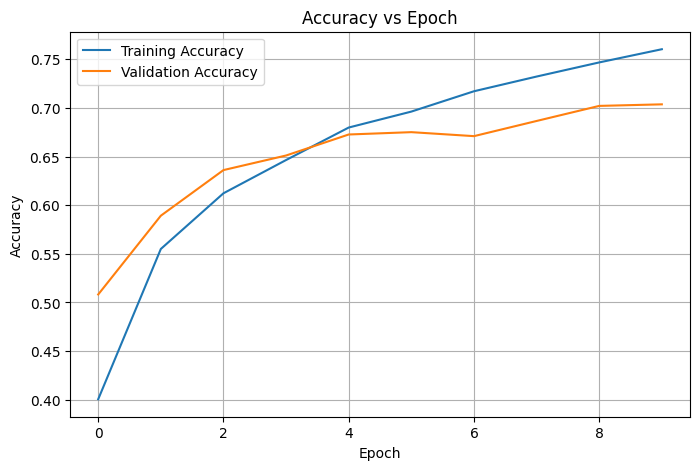

In [ ]:
# Plot training and validation accuracy

plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Accuracy vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

Plot Loss vs Epoch

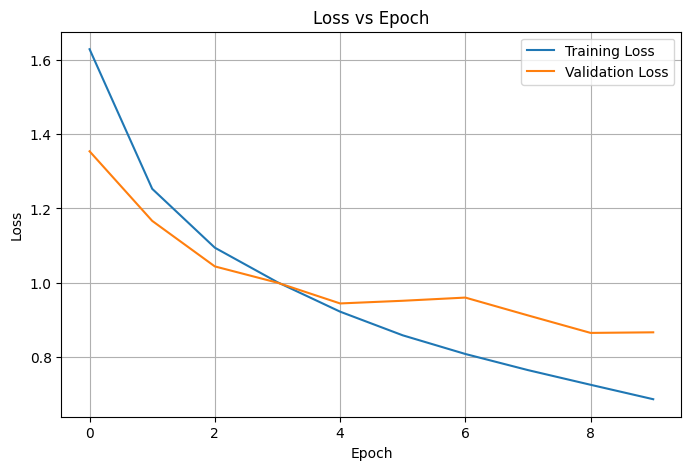

In [ ]:
# Plot training and validation loss

plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Loss vs Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

Evaluate the CNN on Test Data

In [ ]:
# Evaluate the model on test data

test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=1)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7073 - loss: 0.8621
Test Loss: 0.8620550036430359
Test Accuracy: 0.7073000073432922
Test Accuracy (%): 70.73000073432922


# TASK D — PERFORMANCE ANALYSIS

Generate Predictions

In [ ]:
# Generate predictions for test images

predictions = model.predict(x_test)

# Convert probabilities to class labels
predicted_classes = np.argmax(predictions, axis=1)
true_classes = y_test.flatten()

print("Predictions generated successfully!")
print("Number of predictions:", len(predicted_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Predictions generated successfully!
Number of predictions: 10000


Confusion Matrix

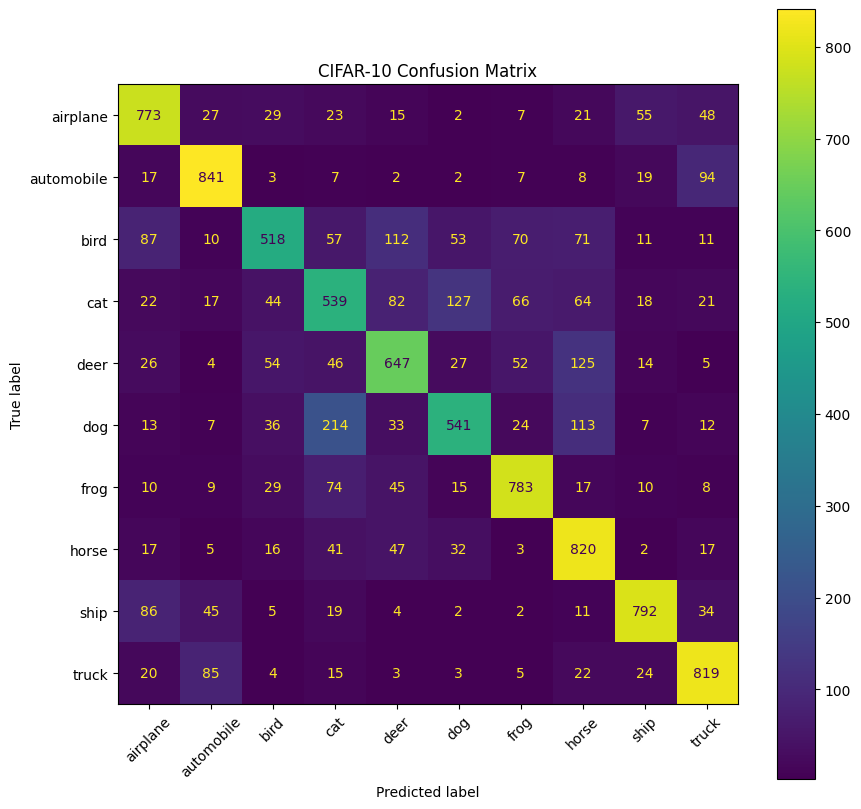

In [ ]:
# Create and display confusion matrix

cm = confusion_matrix(true_classes, predicted_classes)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45)

plt.title("CIFAR-10 Confusion Matrix")
plt.show()

Display Sample Predictions

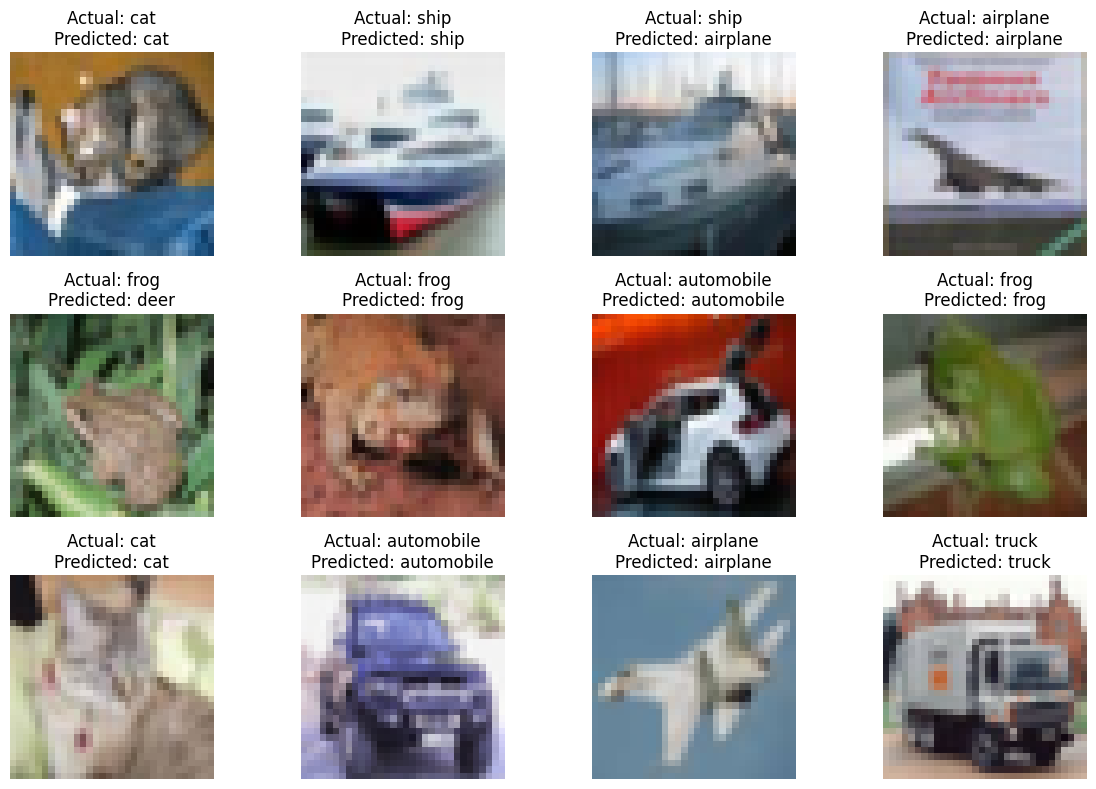

In [ ]:
# Display sample predictions

plt.figure(figsize=(12, 8))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_test[i])

    actual = class_names[true_classes[i]]
    predicted = class_names[predicted_classes[i]]

    plt.title(f"Actual: {actual}\nPredicted: {predicted}")
    plt.axis('off')

plt.tight_layout()
plt.show()

Display Misclassified Images

Number of misclassified images: 2927


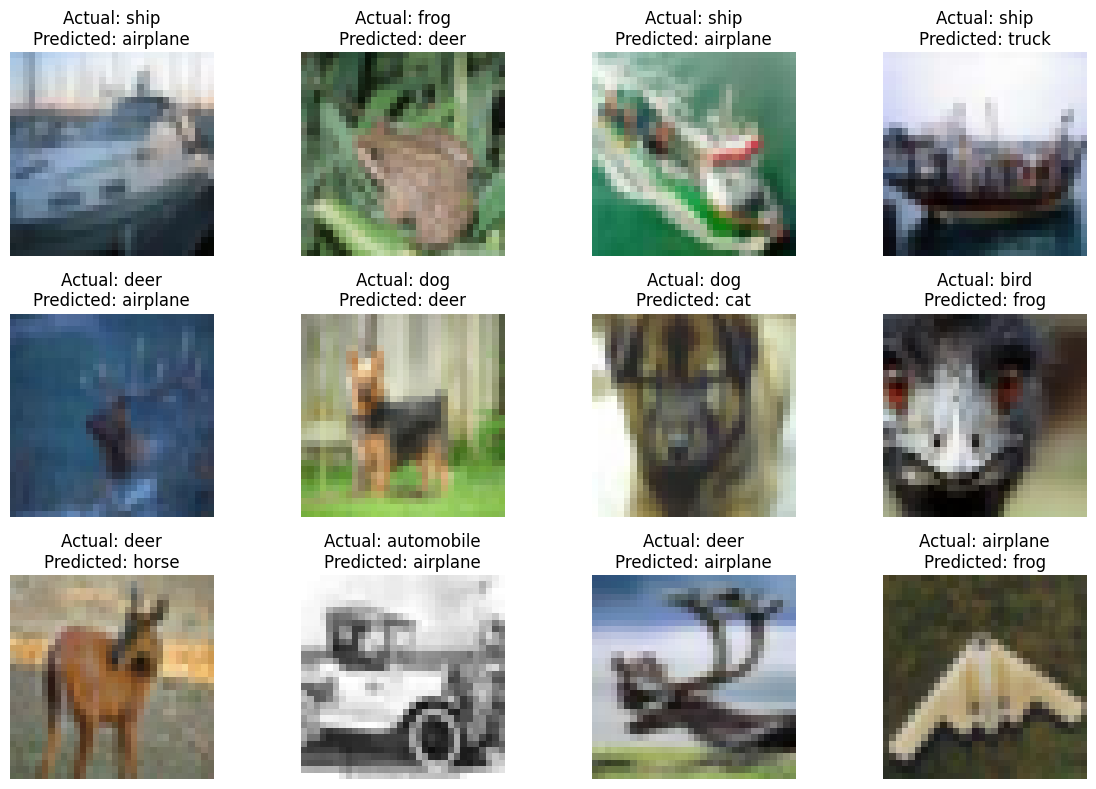

In [ ]:
# Find and display misclassified images

misclassified = np.where(true_classes != predicted_classes)[0]

print("Number of misclassified images:", len(misclassified))

plt.figure(figsize=(12, 8))

for i in range(min(12, len(misclassified))):
    index = misclassified[i]

    plt.subplot(3, 4, i + 1)
    plt.imshow(x_test[index])

    actual = class_names[true_classes[index]]
    predicted = class_names[predicted_classes[index]]

    plt.title(f"Actual: {actual}\nPredicted: {predicted}")
    plt.axis('off')

plt.tight_layout()
plt.show()

Final Performance Summary

In [ ]:
# Final performance summary

final_train_accuracy = history.history['accuracy'][-1]
final_val_accuracy = history.history['val_accuracy'][-1]

print("========== CNN PERFORMANCE SUMMARY ==========")
print(f"Final Training Accuracy   : {final_train_accuracy * 100:.2f}%")
print(f"Final Validation Accuracy : {final_val_accuracy * 100:.2f}%")
print(f"Test Accuracy             : {test_accuracy * 100:.2f}%")
print(f"Test Loss                 : {test_loss:.4f}")
print(f"Misclassified Images      : {len(misclassified)}")
print(f"Correctly Classified      : {len(true_classes) - len(misclassified)}")
print("==============================================")

========== CNN PERFORMANCE SUMMARY ==========
Final Training Accuracy   : 76.04%
Final Validation Accuracy : 70.37%
Test Accuracy             : 70.73%
Test Loss                 : 0.8621
Misclassified Images      : 2927
Correctly Classified      : 7073
